# Analysis of H3


Shifts in feminist theoretical orientation within Heresies will coincide with changes in patterns of contribution, including the emergence of new contributors and changing thematic emphases associated with the magazine's rotating collectives.

Your methods are: contributor frequency, frequency analysis, segmentation

What the analysis needs to show:

- Who contributed most overall
- Which contributors appear in which volume — do new names emerge over time?
- Are there contributors unique to one period — appearing only in early, middle or late issues?

#### 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import re

#### 2. Loading Dataset

In [2]:
df = pd.read_csv("/Users/sophiehamann/master-thesis-code/data/output_files/09_h3_contributors.csv")
print(df.shape)
print(df["volume"].value_counts())

(1113, 5)
volume
Vol1_late1970s     394
Vol3_late1980s     330
Vol2_early1980s    265
Vol4_early1990s    124
Name: count, dtype: int64


#### 3. Overall Contributor Frequency

In [3]:
overall_freq = df["person"].value_counts().head(20)
print(overall_freq)

person
JOAN BRADERMAN       11
Su Friedrich         10
Amy Sillman           6
Howardena Pindell     5
Mary Beth Edelson     5
Dee Shapiro           5
Roberta Neiman        5
V. E. Browne          5
Louise Fishman        4
Betsy Damon           4
Anne Healy            4
Harmony Hammond       4
Joan Jonas            4
Gwendolyn Wright      4
Valerie Harris        4
Lyn Hughes            3
Cynthia Carr          3
Willi Posey           3
Lynda Benglis         3
Louise Bourgeois      3
Name: count, dtype: int64


#### 4. Graph 1: Top Contributors Overall
Using this: https://www.geeksforgeeks.org/pandas/bar-plot-in-matplotlib/

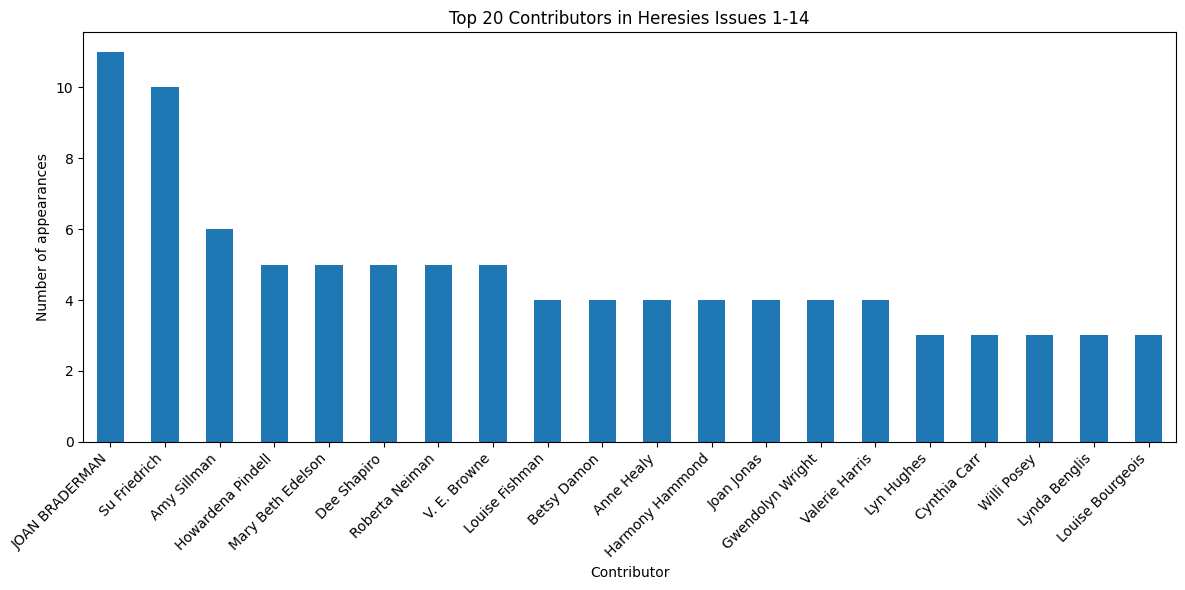

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
overall_freq.plot(kind="bar", ax=ax)
ax.set_xlabel("Contributor")
ax.set_ylabel("Number of appearances")
ax.set_title("Top 20 Contributors in Heresies Issues 1-14")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_overall_frequency.png")
plt.show()

#### Graph 1b: Top contributors per issue

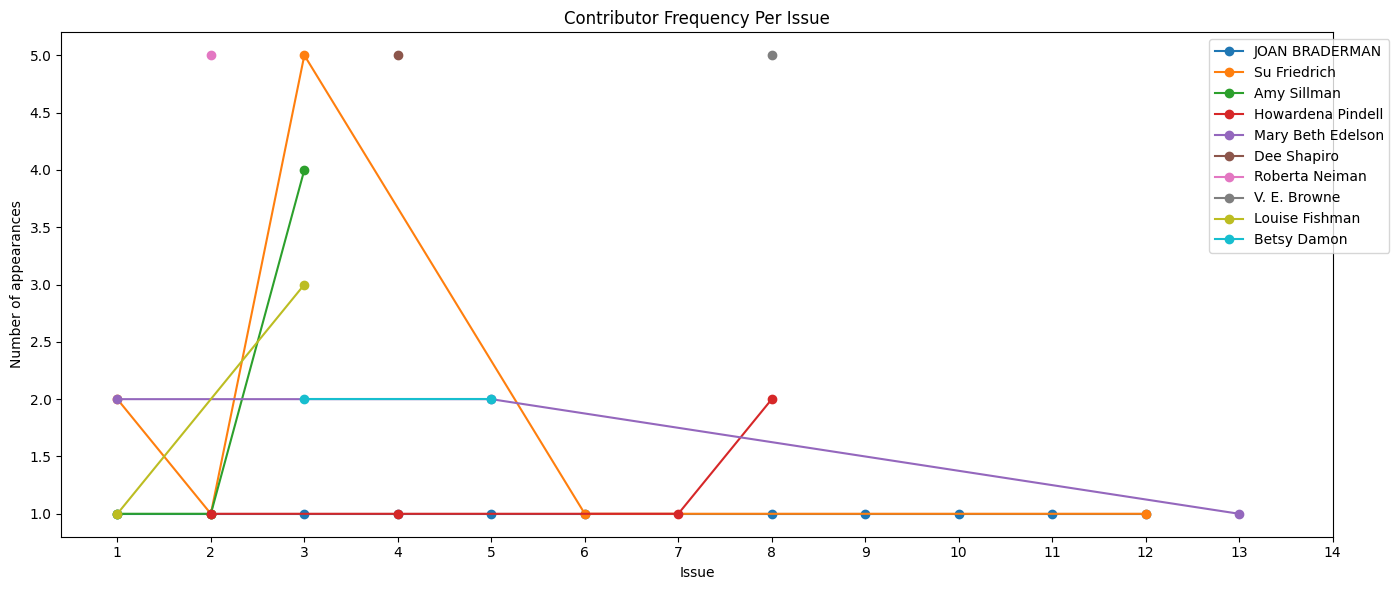

In [ ]:
issue_freq = df.groupby(["issue", "person"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(14, 6))

for person in top_contributors:
    person_data = issue_freq[issue_freq["person"] == person]
    ax.plot(person_data["issue"], person_data["count"], marker="o", label=person)

ax.set_xlabel("Issue")
ax.set_ylabel("Number of appearances")
ax.set_title("Contributor Frequency Per Issue")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(range(1, 15))
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_issue_frequency.png")
plt.show()

#### 5. Contributor Frequency per volume

In [5]:
volume_freq = df.groupby(["volume", "person"]).size().reset_index(name="count")
print(volume_freq.head(20))

            volume               person  count
0   Vol1_late1970s       ANN LAUTERBACH      1
1   Vol1_late1970s           ANN SPERRY      1
2   Vol1_late1970s       Adelaide Alsop      1
3   Vol1_late1970s       Adele Blumberg      1
4   Vol1_late1970s        Adrienne Rich      2
5   Vol1_late1970s             Al Mozeh      1
6   Vol1_late1970s  Alexandra Kollantai      1
7   Vol1_late1970s         Alice Austen      3
8   Vol1_late1970s         Alice Aycock      1
9   Vol1_late1970s      Alice B. Toklas      1
10  Vol1_late1970s  Alice Watters Beebe      2
11  Vol1_late1970s         Alma Buscher      1
12  Vol1_late1970s          Amy Sillman      6
13  Vol1_late1970s            Anaïs Nin      2
14  Vol1_late1970s         Andre Morain      1
15  Vol1_late1970s    Angela Balabanoff      1
16  Vol1_late1970s        Angry Harmony      1
17  Vol1_late1970s        Anita Steckel      1
18  Vol1_late1970s     Ann Leda Shapiro      1
19  Vol1_late1970s         Ann Newmarch      1


#### 6. Graph 2: Top Contributors per Volume

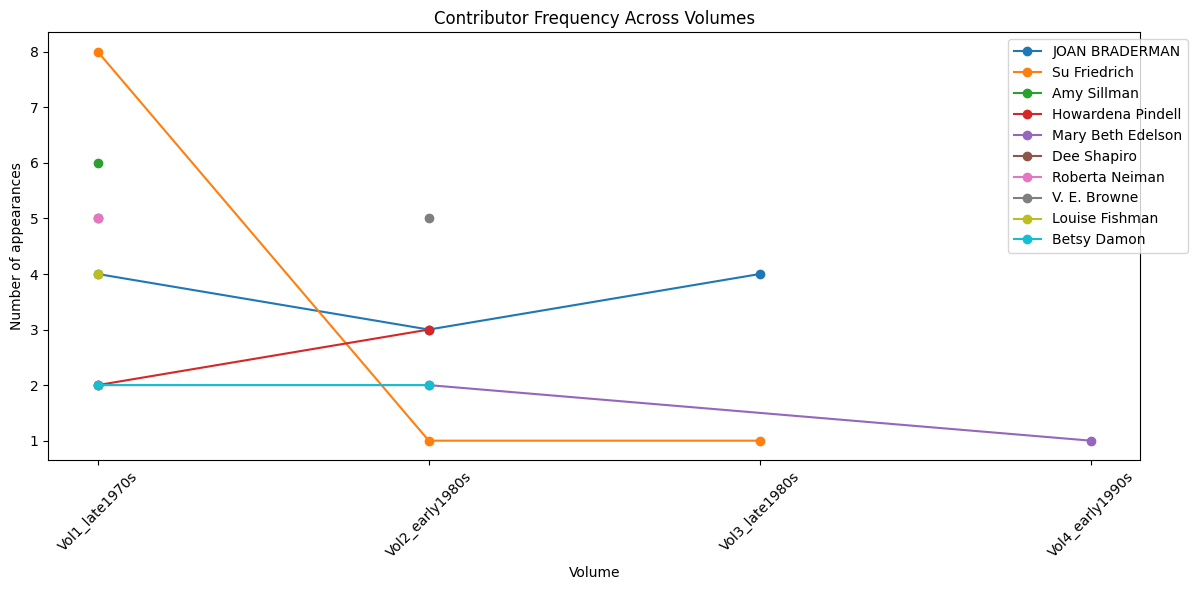

In [6]:
volumes = df["volume"].unique()
top_contributors = df["person"].value_counts().head(10).index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))

for person in top_contributors:
    person_data = volume_freq[volume_freq["person"] == person]
    ax.plot(person_data["volume"], person_data["count"], marker="o", label=person)

ax.set_xlabel("Volume")
ax.set_ylabel("Number of appearances")
ax.set_title("Contributor Frequency Across Volumes")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_volume_frequency.png")
plt.show()

#### Top Contributors per issue

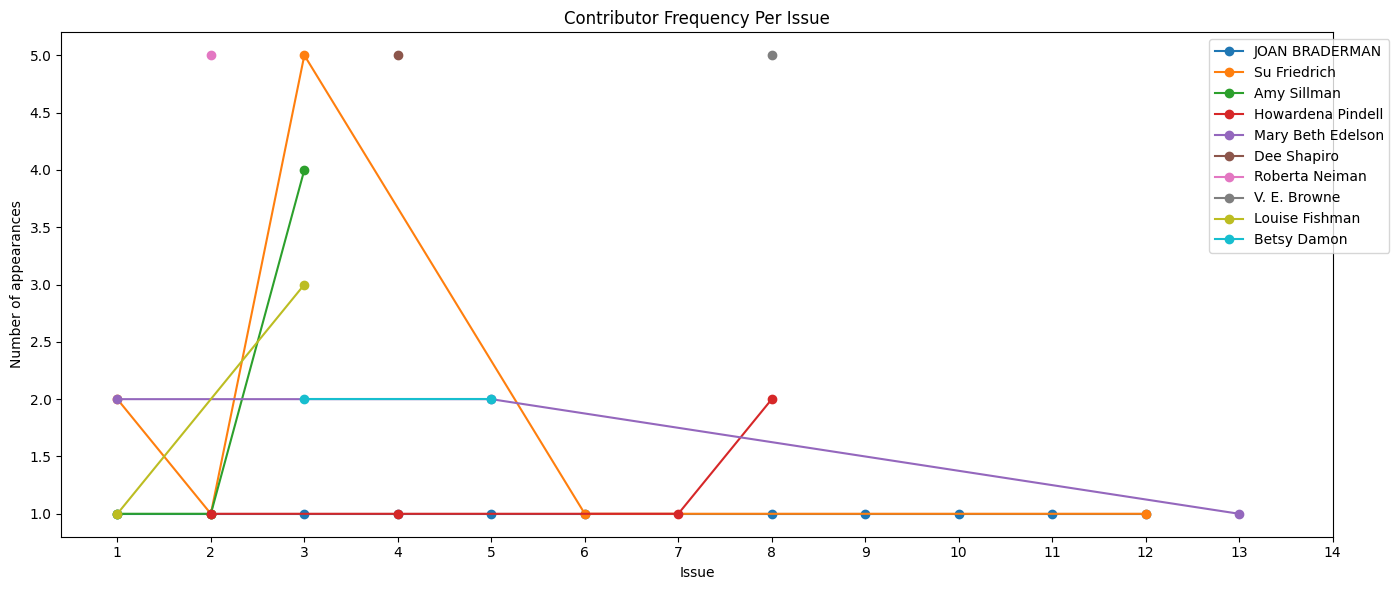

In [14]:
issue_freq = df.groupby(["issue", "person"]).size().reset_index(name="count")

fig, ax = plt.subplots(figsize=(14, 6))

for person in top_contributors:
    person_data = issue_freq[issue_freq["person"] == person]
    ax.plot(person_data["issue"], person_data["count"], marker="o", label=person)

ax.set_xlabel("Issue")
ax.set_ylabel("Number of appearances")
ax.set_title("Contributor Frequency Per Issue")
ax.legend(bbox_to_anchor=(1.05, 1))
plt.xticks(range(1, 15))
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_issue_frequency.png")
plt.show()

#### 7. New Contributors per Volume

In [7]:
# find contributors who appear for the first time in each volume
first_appearance = df.groupby("person")["issue"].min().reset_index()
first_appearance.columns = ["person", "first_issue"]

def get_volume(issue_nr):
    if issue_nr <= 4:
        return "Vol1_late1970s"
    elif issue_nr <= 8:
        return "Vol2_early1980s"
    elif issue_nr <= 12:
        return "Vol3_late1980s"
    elif issue_nr <= 16:
        return "Vol4_early1990s"
    else:
        return "Vol5+"

first_appearance["first_volume"] = first_appearance["first_issue"].apply(get_volume)

new_per_volume = first_appearance["first_volume"].value_counts()
print("New contributors per volume:")
print(new_per_volume)

New contributors per volume:
first_volume
Vol1_late1970s     320
Vol3_late1980s     224
Vol2_early1980s    200
Vol4_early1990s     93
Name: count, dtype: int64


#### 7b. New Contributors per Issue

New contributors per issue:
first_issue
1     63
2     82
3     78
4     97
5     81
6     35
7     25
8     59
9     23
10    82
11    62
12    57
13    85
14     8
Name: count, dtype: int64


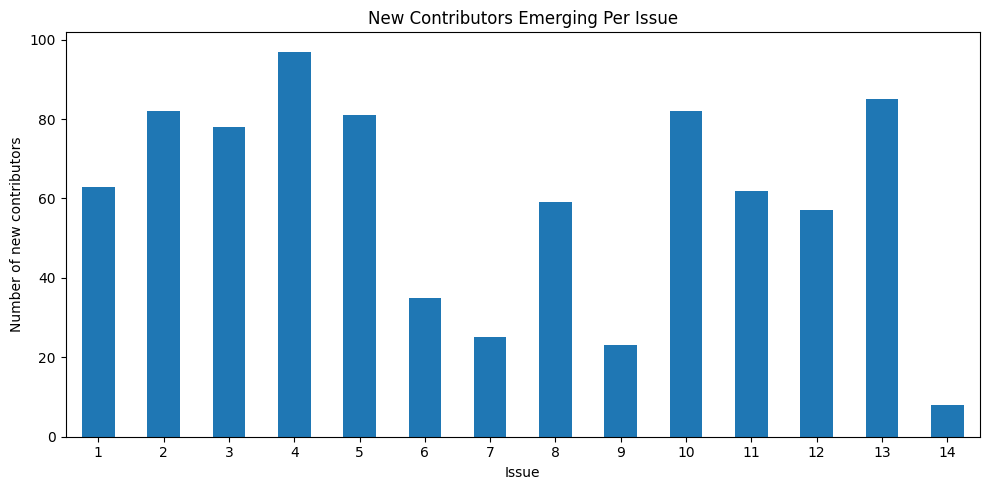

In [15]:
new_per_issue = first_appearance["first_issue"].value_counts().sort_index()
print("New contributors per issue:")
print(new_per_issue)

fig, ax = plt.subplots(figsize=(10, 5))
new_per_issue.plot(kind="bar", ax=ax)
ax.set_xlabel("Issue")
ax.set_ylabel("Number of new contributors")
ax.set_title("New Contributors Emerging Per Issue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_contributors_issue.png")
plt.show()

#### 8. Graph 3: New Contributors per volume

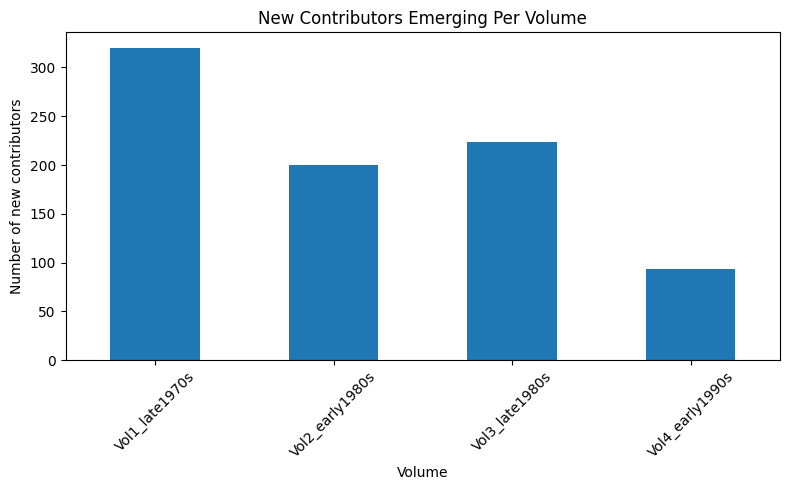

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
new_per_volume.sort_index().plot(kind="bar", ax=ax)
ax.set_xlabel("Volume")
ax.set_ylabel("Number of new contributors")
ax.set_title("New Contributors Emerging Per Volume")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("/Users/sophiehamann/master-thesis-code/data/output_files/graph_h3_new_contributors.png")
plt.show()

#### 9. Contributors unique to one volume

In [9]:
# find contributors who appear in only one volume
volume_count = df.groupby("person")["volume"].nunique().reset_index()
volume_count.columns = ["person", "volumes_active"]

unique_contributors = volume_count[volume_count["volumes_active"] == 1]
print(f"Contributors appearing in only one volume: {len(unique_contributors)}")

# show which volume they belong to
unique_with_volume = unique_contributors.merge(first_appearance[["person", "first_volume"]], on="person")
print(unique_with_volume["first_volume"].value_counts())

Contributors appearing in only one volume: 792
first_volume
Vol1_late1970s     286
Vol3_late1980s     223
Vol2_early1980s    190
Vol4_early1990s     93
Name: count, dtype: int64


#### 9b. Contributors unique to one issue

In [16]:
issue_count = df.groupby("person")["issue"].nunique().reset_index()
issue_count.columns = ["person", "issues_active"]

unique_issue = issue_count[issue_count["issues_active"] == 1]
print(f"Contributors appearing in only one issue: {len(unique_issue)}")

unique_with_issue = unique_issue.merge(first_appearance[["person", "first_issue"]], on="person")
print(unique_with_issue["first_issue"].value_counts().sort_index())

Contributors appearing in only one issue: 781
first_issue
1     48
2     70
3     71
4     91
5     75
6     31
7     24
8     57
9     21
10    81
11    62
12    57
13    85
14     8
Name: count, dtype: int64


#### 10. Saving the results

In [17]:
volume_freq.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/10_h3_volume_frequency.csv", index=False)
first_appearance.to_csv("/Users/sophiehamann/master-thesis-code/data/output_files/10_h3_first_appearance.csv", index=False)